In [1]:
from scipy.optimize import curve_fit
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import os 
import sys

fontsize = 15

# Part 1: Semiconductor Zener diode

### Current vs voltage (forward + reverse bias)

In [2]:
data = pd.read_csv('../data/data1.txt', delimiter='\t')
data

,V (V),dV (V),I (A),dI (A)
0,-6.864,0.0001,-6.910000e-02,1.000000e-04
1,-6.500,0.0001,-6.400000e-07,1.000000e-08
2,-6.000,0.0001,-1.380000e-07,2.000000e-10
3,-5.500,0.0001,-4.500000e-08,1.000000e-09
4,-5.000,0.0001,1.720000e-08,2.000000e-10
5,-4.500,0.0001,-7.400000e-09,1.000000e-10
6,-4.000,0.0001,-3.300000e-09,5.000000e-10
7,-3.000,0.0001,-7.600000e-10,2.000000e-11
8,-2.000,0.0001,-1.700000e-10,1.000000e-11
9,-1.000,0.0001,-3.000000e-11,3.000000e-12


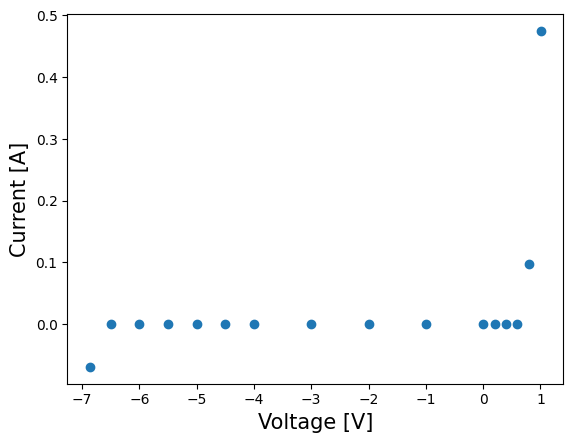

In [3]:
plt.scatter(
    data['V (V)'],
    data['I (A)']
)

plt.xlabel('Voltage [V]', fontsize=fontsize)
plt.ylabel('Current [A]', fontsize=fontsize)
plt.savefig('../tex/figures/data.png')

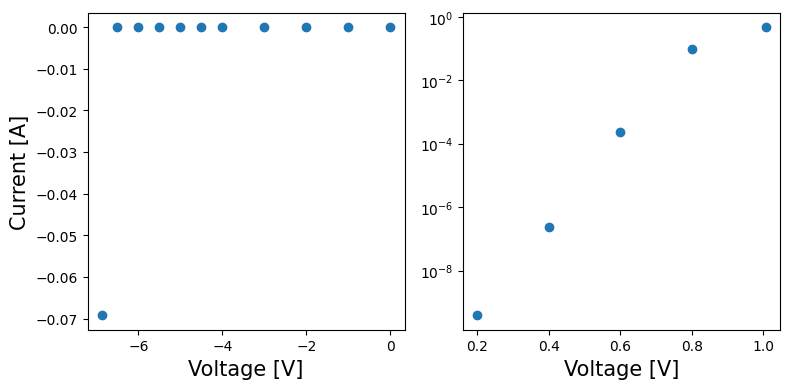

0.0001000633833125


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
temp = data.query('`V (V)` <= 0').reset_index(drop=True)
ax[0].errorbar(
    temp['V (V)'],
    temp['I (A)'],
    xerr=temp['dV (V)'],
    yerr=temp['dI (A)'],
    fmt='o'
)
ax[0].set_xlabel('Voltage [V]', fontsize=fontsize)
ax[0].set_ylabel('Current [A]', fontsize=fontsize)


temp = data.query('`V (V)` > 0').reset_index(drop=True)
ax[1].scatter(
    temp['V (V)'],
    temp['I (A)']
)
ax[1].set_xlabel('Voltage [V]', fontsize=fontsize)
# ax[1].set_ylabel('Current [A]', fontsize=fontsize)
ax[1].set_yscale('log')

plt.tight_layout()
plt.savefig('../tex/figures/part_1_current_vs_voltage_back_and_forward_bias.png', dpi=300,
            bbox_inches='tight')
plt.show()

print(data['dI (A)'].mean())

### Current vs Voltage (full range)

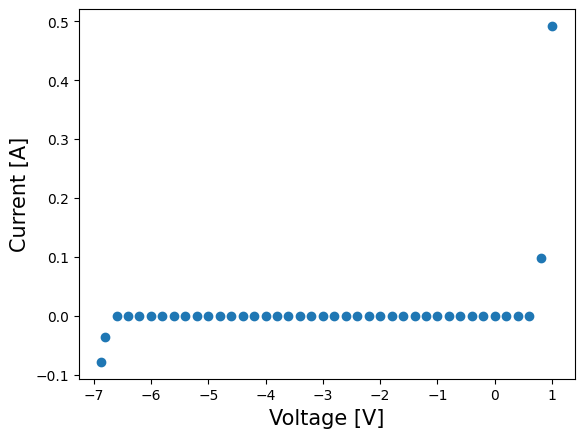

In [5]:
data2 = pd.read_csv('../data/data2.txt', delimiter='\t')
data2
plt.scatter(
    data2['V (V)'],
    data2['I (A)'],
    # alpha=0.5
)

plt.xlabel('Voltage [V]', fontsize=fontsize)
plt.ylabel('Current [A]', fontsize=fontsize)
plt.savefig('../tex/figures/data2.png')

### Forward Bias

In [6]:
forward_bias = pd.read_csv('../data/part1_forward_bias.txt', delimiter='\t')
voltage = forward_bias['V (V)']
voltage_err = forward_bias['dV (V)']
current = forward_bias['I (A)']
current_err = forward_bias['dI (A)']
forward_bias

,V (V),dV (V),I (A),dI (A)
0,0.00,0.0001,-1.000000e-12,1.000000e-12
1,0.01,0.0001,-1.000000e-12,1.000000e-12
2,0.02,0.0001,1.000000e-12,1.000000e-12
3,0.03,0.0001,4.000000e-12,1.000000e-12
4,0.04,0.0001,5.000000e-12,1.000000e-12
...,...,...,...,...
61,0.61,0.0001,3.590000e-04,1.000000e-06
62,0.62,0.0001,5.190000e-04,1.000000e-06
63,0.63,0.0001,7.560000e-04,1.000000e-06
64,0.64,0.0001,1.092000e-03,1.000000e-06


I_0: 3.7187277717451056e-13
I_0 err: 1.5902461887714386e-14
n_fit: 1.1466421547666936
n_err: 0.0034357382537298273


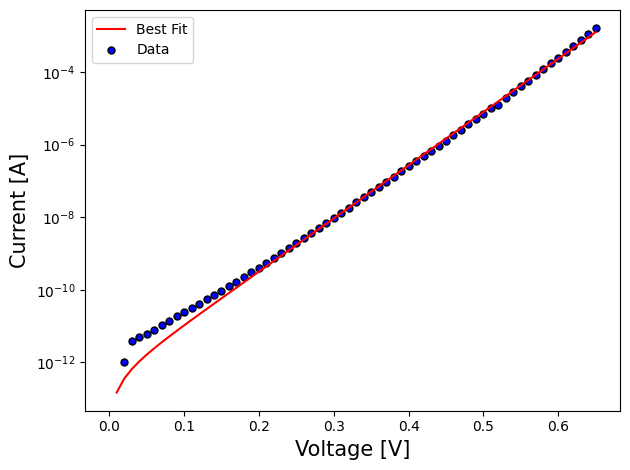

In [7]:
def diode_equation(V, I0, n):
    e = 1.60217663e-19  # Electron charge
    k = 1.380649e-23   # Boltzmann constant
    T = 300            # Temperature in Kelvin
    # Vt = (k * T) / e
    # return I0 * (np.exp(V / (n * Vt)) - 1)
    return I0 * (np.exp((e * V) / (n * k * T)) - 1)

initial_guess = [1e-9, 1.11]
popt, pcov = curve_fit(
    diode_equation, 
    voltage, 
    current, 
    p0=initial_guess, 
    sigma=forward_bias['dI (A)'],
    bounds=(0, np.inf),
    )

I_0_fit, n_fit = popt
I_0_fit_err, n_fit_err = np.sqrt(np.diag(pcov))
print(f'I_0: {I_0_fit}')
print(f'I_0 err: {I_0_fit_err}')
print(f'n_fit: {n_fit}')
print(f'n_err: {n_fit_err}')

# plt.figure(figsize=(8, 4))
# plt.scatter(voltage, current, label='Data', 
#             # c='blue', 
#             # alpha=0.6,
#             marker='o',
#             s=50,
#             edgecolors='black',
#             facecolors='none'
# )

plt.errorbar(
    voltage,
    current, 
    # xerr=voltage_err,
    # yerr=current_err,
    fmt='o',
    ms=5,
    elinewidth=0.5,
    capsize=2,
    # mfc='none',
    mec='black',
    label='Data',
    color='blue',
)

plt.plot(voltage[1:], diode_equation(voltage[1:], *popt), 'r-', label='Best Fit', zorder=5)
plt.xlabel('Voltage [V]', fontsize=fontsize)
plt.ylabel('Current [A]', fontsize=fontsize)
plt.legend()
plt.yscale('log')
# plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.savefig('../tex/figures/part1_forward_bias_current_vs_voltage.png', dpi=300, bbox_inches='tight')
plt.show()

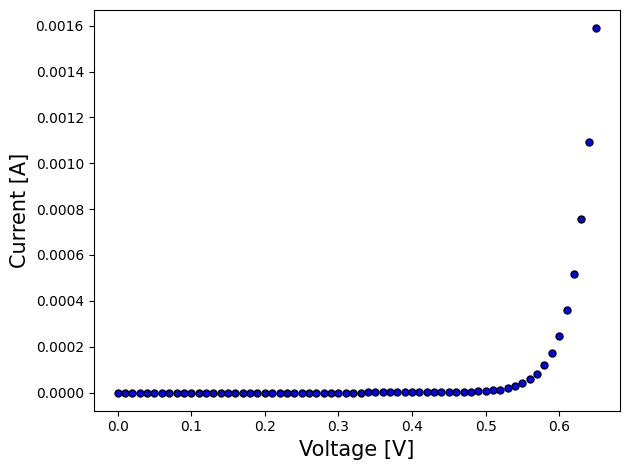

In [8]:
plt.errorbar(
    voltage,
    current, 
    xerr=voltage_err,
    yerr=current_err,
    fmt='o',
    ms=5,
    elinewidth=0.5,
    capsize=2,
    # mfc='none',
    mec='black',
    label='Data',
    color='blue',
)
plt.xlabel('Voltage [V]', fontsize=fontsize)
plt.ylabel('Current [A]', fontsize=fontsize)
plt.tight_layout()
plt.savefig('../tex/figures/part_1_shielded_forward_bias_no_fit.png')

# Germanium diode

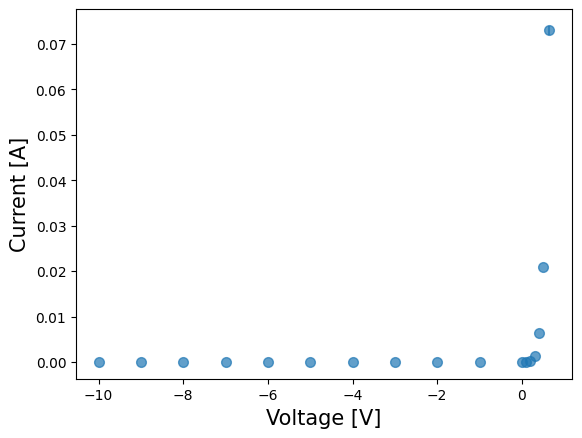

In [9]:
unshielded = pd.read_csv('../data/germanium_diode_full_range.txt', delimiter='\t')

plt.errorbar(
    unshielded['V (V)'],
    unshielded['I (A)'],
    xerr=0.0001,
    yerr=unshielded['dI (A)'],
   ms=7,
   alpha=0.7 ,
   fmt='o'
)
plt.xlabel('Voltage [V]', fontsize=fontsize)
plt.ylabel('Current [A]', fontsize=fontsize)
plt.savefig('../tex/figures/part_3_full_range.png', dpi=300, bbox_inches='tight')

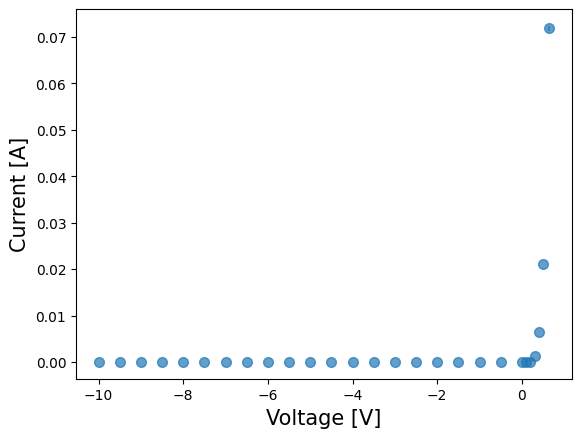

In [10]:
shielded = pd.read_csv('../data/germanium_diode_shielded_full_range.txt', delimiter='\t')

plt.errorbar(
    shielded['V (V)'],
    shielded['I (A)'],
    xerr=0.0001,
    yerr=shielded['dI (A)'],
   ms=7,
   alpha=0.7 ,
   fmt='o'
)
plt.xlabel('Voltage [V]', fontsize=fontsize)
plt.ylabel('Current [A]', fontsize=fontsize)
plt.savefig('../tex/figures/part_3_shielded_full_range.png', dpi=300, bbox_inches='tight')

## Fitting on the forward bias

In [11]:
data = pd.read_csv('../data/germanium_diode_forward_bias.txt', delimiter='\t')
data

,V (V),dV (V),I (A),dI (A)
0,0.010,0.0001,3.640000e-07,1.000000e-09
1,0.020,0.0001,8.320000e-07,3.000000e-09
2,0.030,0.0001,1.505000e-06,2.000000e-09
3,0.040,0.0001,2.370000e-06,1.000000e-08
4,0.050,0.0001,3.570000e-06,1.000000e-08
...,...,...,...,...
60,0.610,0.0001,5.386000e-02,2.000000e-05
61,0.620,0.0001,5.764000e-02,2.000000e-05
62,0.630,0.0001,6.185000e-02,2.000000e-05
63,0.640,0.0001,6.617000e-02,3.000000e-05


8.290095336391412e-06 2.6548071281516417
[1.13356072e-06 5.16477790e-02]
6.192553846153846e-06


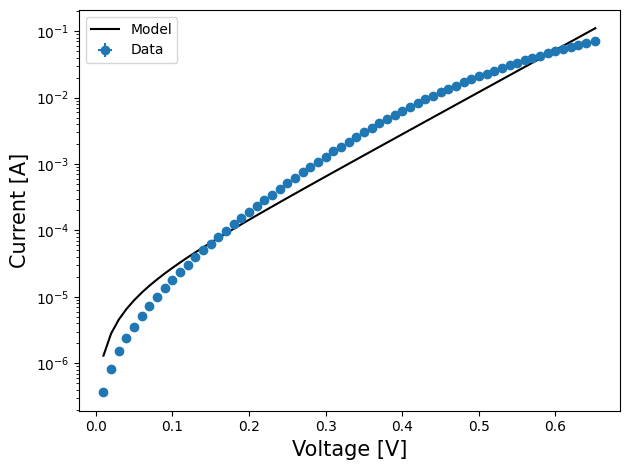

In [12]:
plt.errorbar(
    data['V (V)'],
    data['I (A)'],
    label='Data',
    yerr=data['dI (A)'],
    xerr=data['dV (V)'],
    fmt='o'
)

initial_guess = [100e-6, 2]
popt, pcov = curve_fit(diode_equation, data['V (V)'], data['I (A)'],
                       p0=initial_guess,
                       sigma=data['dI (A)'],
                       bounds=(0, np.inf)
            )

print(*popt)
print(np.sqrt(np.diag(pcov)))
plt.plot(data['V (V)'], diode_equation(data['V (V)'], *popt), c='k', label='Model')
plt.xlabel('Voltage [V]', fontsize=fontsize)
plt.ylabel('Current [A]', fontsize=fontsize)
plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.savefig('../tex/figures/germanium_diode_fit.png', bbox_inches='tight', dpi=300)
print(data['dI (A)'].mean())

# Physics of light emitting diodes

In [13]:
def linear_fit(x, m, b):
    '''Perform a linear fit to data'''
    return m * x + b

def find_intersection(m1, b1, m2, b2):
    '''Find the intersection between two lines'''
    xi = (b2 - b1) / (m1 - m2)
    yi = m1 * xi + b1
    return xi, yi

def uncertainty(m1, b1, m1_err, b1_err, m2, b2, m2_err, b2_err):
    '''Find the uncertainty of the intersection above'''
    term1 = (b2 - b1) / (m2 - m1) * m2_err
    term2 = (b2 - b1) / (m2 - m1) * m1_err
    term3 = 1 / (m2 - m1) * b2_err 
    term4 = 1 / (m2 - m1) * b1_err
    return np.sqrt(term1**2 + term2**2 + term3**2 + term4**2)

## $\lambda = 385$ nm

m1 =  7.095828914842343e-06 +- 4.42124121304995e-06
b1 = -6.478211060827446e-06 +- 9.702493286051185e-06
m2 =  0.22806857139297593 +- 0.009307115757699817
b2 = -0.7231068570191628 +- 0.03239658463809009
x_intersection = 3.170637991443616 +- 0.1450847266290695
current error 0.0001723758620689655
Voltage error 9.999999999999998e-05


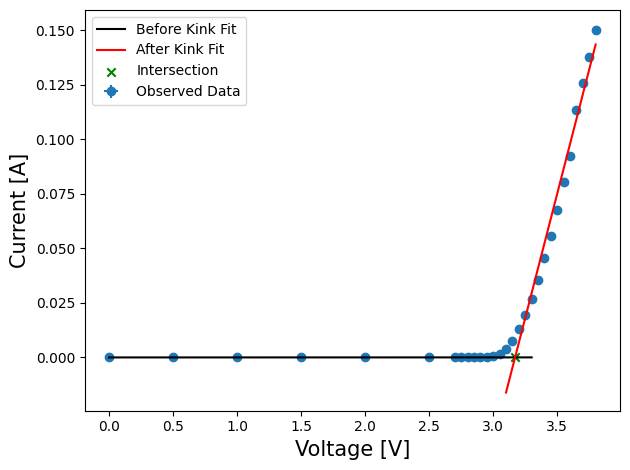

In [14]:
lambda385 = pd.read_csv('../data/385nm.txt', delimiter='\t')
voltage = lambda385['V (V)']
current = lambda385['I (A)']
lambda385['dV (V)'] = 0.0001 # V

kink_index = 11
plt.errorbar(
    voltage, 
    current,
    fmt='o',
    xerr=lambda385['dV (V)'],
    yerr=lambda385['dI (A)'],
    label='Observed Data'
)
popt, pcov = curve_fit(linear_fit, voltage[:kink_index], current[:kink_index])
m1, b1 = popt
m1_err, b1_err = np.sqrt(np.diag(pcov))
print(f'm1 =  {m1} +- {m1_err}')
print(f'b1 = {b1} +- {b1_err}')

popt_, pcov_ = curve_fit(linear_fit, voltage[kink_index + 4:], current[kink_index + 4:])
m2, b2 = popt_
m2_err, b2_err = np.sqrt(np.diag(pcov_))
print(f'm2 =  {m2} +- {m2_err}')
print(f'b2 = {b2} +- {b2_err}')
                         
plt.plot(
    voltage[:kink_index + 8],
    linear_fit(voltage[:kink_index + 8], *popt),
    c='k',
    label='Before Kink Fit',
    zorder=10,
)
plt.plot(
    voltage[kink_index  + 3:],
    linear_fit(voltage[kink_index + 3:], *popt_),
    c='red',
    zorder=12,
    label='After Kink Fit'
)

x_int, y_int = find_intersection(*popt, *popt_)
x_int_err = uncertainty(*popt, *np.sqrt(np.diag(pcov)), *popt_, *np.sqrt(np.diag(pcov_)))
print(f'x_intersection = {x_int} +- {x_int_err}')
# print(f'y_intersection')
print(f'current error {lambda385["dI (A)"].mean()}')
print(f'Voltage error {lambda385["dV (V)"].mean()}')
plt.scatter(x_int, y_int, color='green', marker='x', label='Intersection')

plt.xlabel('Voltage [V]', fontsize=fontsize)
plt.ylabel('Current [A]', fontsize=fontsize)
plt.legend()
plt.tight_layout()
plt.savefig('../tex/figures/385nm.png', dpi=300, bbox_inches='tight')
plt.show()

## $\lambda = 466$ nm

m1 =  2.0414966862892752e-05 +- 7.823003847624096e-06
b1 = -1.5688630854999766e-05 +- 1.6492105792415553e-05
m2 =  0.014782424202494171 +- 0.0011937872768305994
b2 = -0.04501353926316806 +- 0.003913410574374678
x_intersection = 3.048219921425133 +- 0.26512745927567133
current error 4.183508576923077e-06


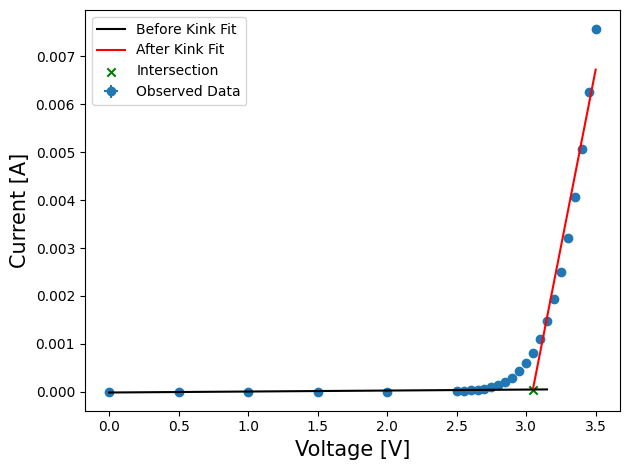

In [15]:
lambda466 = pd.read_csv('../data/466nm.txt', delimiter='\t')
voltage = lambda466['V (V)']
current = lambda466['I (A)']

kink_index = 11
plt.errorbar(
    voltage, 
    current,
    fmt='o',
    xerr=lambda466['dV (V)'],
    yerr=lambda466['dI (A)'],
    label='Observed Data'
)
popt, pcov = curve_fit(linear_fit, voltage[:kink_index], current[:kink_index])
m1, b1 = popt
m1_err, b1_err = np.sqrt(np.diag(pcov))
print(f'm1 =  {m1} +- {m1_err}')
print(f'b1 = {b1} +- {b1_err}')

popt_, pcov_ = curve_fit(linear_fit, voltage[kink_index + 5:], current[kink_index + 5:])
m2, b2 = popt_
m2_err, b2_err = np.sqrt(np.diag(pcov_))
print(f'm2 =  {m2} +- {m2_err}')
print(f'b2 = {b2} +- {b2_err}')
                         
plt.plot(
    voltage[:kink_index + 8],
    linear_fit(voltage[:kink_index + 8], *popt),
    c='k',
    label='Before Kink Fit',
    zorder=10,
)
plt.plot(
    voltage[kink_index + 5:],
    linear_fit(voltage[kink_index + 5:], *popt_),
    c='red',
    zorder=12,
    label='After Kink Fit'
)

x_int, y_int = find_intersection(*popt, *popt_)
x_int_err = uncertainty(*popt, *np.sqrt(np.diag(pcov)), *popt_, *np.sqrt(np.diag(pcov_)))
print(f'x_intersection = {x_int} +- {x_int_err}')
# print(f'y_intersection')]
print(f'current error {lambda466["dI (A)"].mean()}')
plt.scatter(x_int, y_int, color='green', marker='x', label='Intersection')

plt.xlabel('Voltage [V]', fontsize=fontsize)
plt.ylabel('Current [A]', fontsize=fontsize)
plt.legend()
plt.tight_layout()
plt.savefig('../tex/figures/466nm.png', dpi=300, bbox_inches='tight')
plt.show()

## $\lambda = 563$

m1 =  0.00010429248687340076 +- 6.705945630333703e-05
b1 = -5.064767506346919e-05 +- 7.645954414526905e-05
m2 =  0.024740419608426142 +- 0.00048373883737357857
b2 = -0.04532552804064405 +- 0.001196866730984803
x_intersection = 1.8377434140600846 +- 0.048689076630350644
current error 5.142857142857142e-06


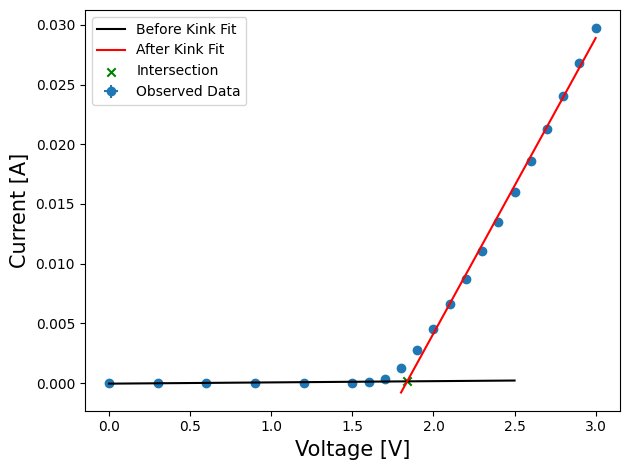

In [16]:
lambda563 = pd.read_csv('../data/563nm.txt', delimiter='\t')
voltage = lambda563['V (V)']
current = lambda563['I (A)']

kink_index = 8
plt.errorbar(
    voltage, 
    current,
    fmt='o',
    xerr=lambda563['dV (V)'],
    yerr=lambda563['dI (A)'],
    label='Observed Data'
)
popt, pcov = curve_fit(linear_fit, voltage[:kink_index], current[:kink_index])
m1, b1 = popt
m1_err, b1_err = np.sqrt(np.diag(pcov))
print(f'm1 =  {m1} +- {m1_err}')
print(f'b1 = {b1} +- {b1_err}')

popt_, pcov_ = curve_fit(linear_fit, voltage[kink_index + 1:], current[kink_index + 1:])
m2, b2 = popt_
m2_err, b2_err = np.sqrt(np.diag(pcov_))
print(f'm2 =  {m2} +- {m2_err}')
print(f'b2 = {b2} +- {b2_err}')
                         
plt.plot(
    voltage[:kink_index + 8],
    linear_fit(voltage[:kink_index + 8], *popt),
    c='k',
    label='Before Kink Fit',
    zorder=10,
)
plt.plot(
    voltage[kink_index:],
    linear_fit(voltage[kink_index:], *popt_),
    c='red',
    zorder=12,
    label='After Kink Fit'
)

x_int, y_int = find_intersection(*popt, *popt_)
x_int_err = uncertainty(*popt, *np.sqrt(np.diag(pcov)), *popt_, *np.sqrt(np.diag(pcov_)))
print(f'x_intersection = {x_int} +- {x_int_err}')
# print(f'y_intersection')
print(f'current error {lambda563["dI (A)"].mean()}')
plt.scatter(x_int, y_int, color='green', marker='x', label='Intersection')

plt.xlabel('Voltage [V]', fontsize=fontsize)
plt.ylabel('Current [A]', fontsize=fontsize)
plt.legend()
plt.tight_layout()
plt.savefig('../tex/figures/563nm.png', dpi=300, bbox_inches='tight')
plt.show()

## $\lambda = 605$ nm

m1 =  2.572975567572919e-05 +- 1.4245947969315372e-05
b1 = -1.1504078866631415e-05 +- 1.585761841396178e-05
m2 =  0.06622545451661901 +- 0.0021611832240292545
b2 = -0.11987581812198445 +- 0.004495183180882562
x_intersection = 1.810646713048507 +- 0.06801643810437732
current error 1.053181818181818e-05


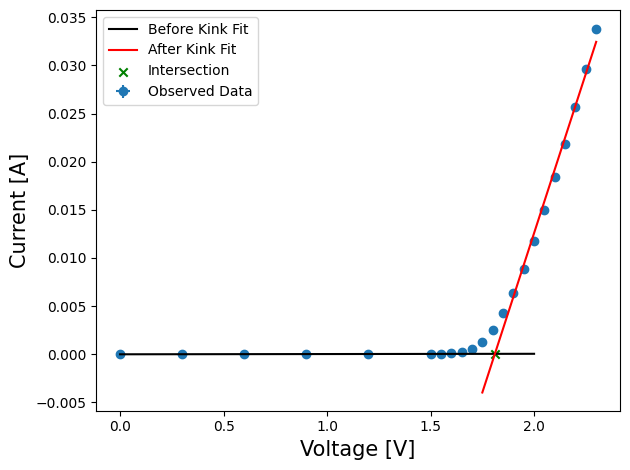

In [17]:
lambda605 = pd.read_csv('../data/605nm.txt', delimiter='\t')
voltage = lambda605['V (V)']
current = lambda605['I (A)']

kink_index = 8
plt.errorbar(
    voltage, 
    current,
    fmt='o',
    xerr=lambda605['dV (V)'],
    yerr=lambda605['dI (A)'],
    label='Observed Data'
)
popt, pcov = curve_fit(linear_fit, voltage[:kink_index], current[:kink_index])
m1, b1 = popt
m1_err, b1_err = np.sqrt(np.diag(pcov))
print(f'm1 =  {m1} +- {m1_err}')
print(f'b1 = {b1} +- {b1_err}')

popt_, pcov_ = curve_fit(linear_fit, voltage[kink_index + 4:], current[kink_index + 4:])
m2, b2 = popt_
m2_err, b2_err = np.sqrt(np.diag(pcov_))
print(f'm2 =  {m2} +- {m2_err}')
print(f'b2 = {b2} +- {b2_err}')
                         
plt.plot(
    voltage[:kink_index + 8],
    linear_fit(voltage[:kink_index + 8], *popt),
    c='k',
    label='Before Kink Fit',
    zorder=10,
)
plt.plot(
    voltage[kink_index + 2:],
    linear_fit(voltage[kink_index + 2:], *popt_),
    c='red',
    zorder=12,
    label='After Kink Fit'
)

x_int, y_int = find_intersection(*popt, *popt_)
x_int_err = uncertainty(*popt, *np.sqrt(np.diag(pcov)), *popt_, *np.sqrt(np.diag(pcov_)))
print(f'x_intersection = {x_int} +- {x_int_err}')
# print(f'y_intersection')
print(f'current error {lambda605["dI (A)"].mean()}')
plt.scatter(x_int, y_int, color='green', marker='x', label='Intersection')

plt.xlabel('Voltage [V]', fontsize=fontsize)
plt.ylabel('Current [A]', fontsize=fontsize)
plt.legend()
plt.tight_layout()
plt.savefig('../tex/figures/605nm.png', dpi=300, bbox_inches='tight')
plt.show()

## $\lambda=635$ nm

m1 =  1.4170605363386172e-05 +- 6.649105554470512e-06
b1 = -6.35418934217525e-06 +- 7.847378800186311e-06
m2 =  0.06931857574776758 +- 0.00291524348435821
b2 = -0.11645954917397018 +- 0.005343464520466346
x_intersection = 1.6803144727285977 +- 0.0772569065959846
current error 5.9749999999999995e-06


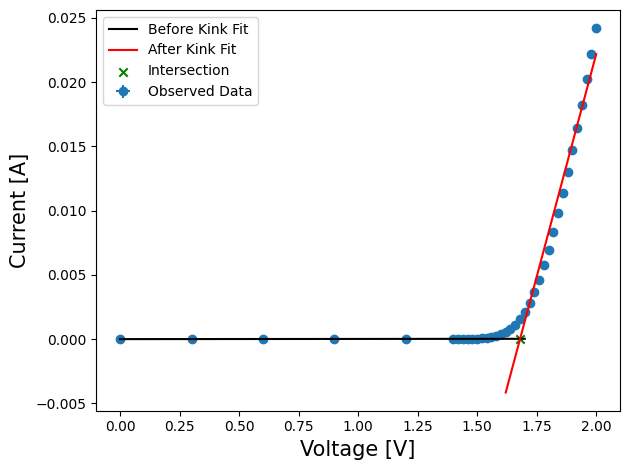

In [18]:
lambda635 = pd.read_csv('../data/635nm.txt', delimiter='\t')
voltage = lambda635['V (V)']
current = lambda635['I (A)']

kink_index = 11
plt.errorbar(
    voltage, 
    current,
    fmt='o',
    xerr=lambda635['dV (V)'],
    yerr=lambda635['dI (A)'],
    label='Observed Data'
)
popt, pcov = curve_fit(linear_fit, voltage[:kink_index], current[:kink_index])
m1, b1 = popt
m1_err, b1_err = np.sqrt(np.diag(pcov))
print(f'm1 =  {m1} +- {m1_err}')
print(f'b1 = {b1} +- {b1_err}')

popt_, pcov_ = curve_fit(linear_fit, voltage[kink_index + 7:], current[kink_index + 7:])
m2, b2 = popt_
m2_err, b2_err = np.sqrt(np.diag(pcov_))
print(f'm2 =  {m2} +- {m2_err}')
print(f'b2 = {b2} +- {b2_err}')
                         
plt.plot(
    voltage[:kink_index + 10],
    linear_fit(voltage[:kink_index + 10], *popt),
    c='k',
    label='Before Kink Fit',
    zorder=10,
)
plt.plot(
    voltage[kink_index  + 5:],
    linear_fit(voltage[kink_index + 5:], *popt_),
    c='red',
    zorder=12,
    label='After Kink Fit'
)

x_int, y_int = find_intersection(*popt, *popt_)
x_int_err = uncertainty(*popt, *np.sqrt(np.diag(pcov)), *popt_, *np.sqrt(np.diag(pcov_)))
print(f'x_intersection = {x_int} +- {x_int_err}')
# print(f'y_intersection')
print(f'current error {lambda635["dI (A)"].mean()}')
plt.scatter(x_int, y_int, color='green', marker='x', label='Intersection')

plt.xlabel('Voltage [V]', fontsize=fontsize)
plt.ylabel('Current [A]', fontsize=fontsize)
plt.legend()
plt.tight_layout()
plt.savefig('../tex/figures/635nm.png', dpi=300, bbox_inches='tight')
plt.show()

## $\lambda = 770$ nm

m1 =  3.326193638490475e-06 +- 2.1441548539198686e-06
b1 = -1.6766980259063506e-06 +- 2.4264803243812522e-06
m2 =  0.14624786187098107 +- 0.010783377321105871
b2 = -0.2572532338630937 +- 0.02041201340171407
x_intersection = 1.7590507294757223 +- 0.1408575736041126
current error 4.5680917083333336e-05


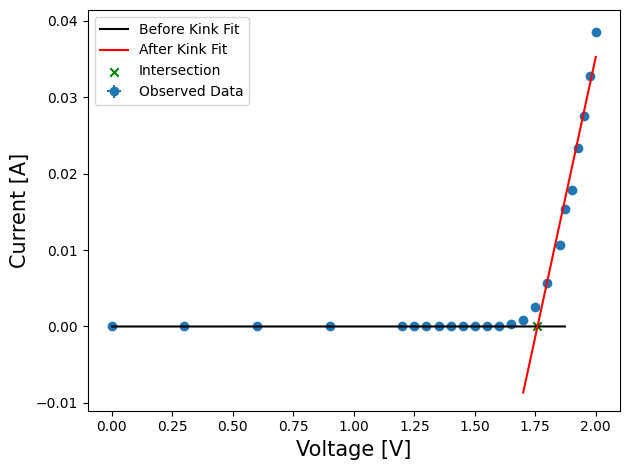

In [19]:
lambda770 = pd.read_csv('../data/770nm.txt', delimiter='\t')
voltage = lambda770['V (V)']
current = lambda770['I (A)']

kink_index = 11
plt.errorbar(
    voltage, 
    current,
    fmt='o',
    xerr=lambda770['dV (V)'],
    yerr=lambda770['dI (A)'],
    label='Observed Data'
)
popt, pcov = curve_fit(linear_fit, voltage[:kink_index], current[:kink_index])
m1, b1 = popt
m1_err, b1_err = np.sqrt(np.diag(pcov))
print(f'm1 =  {m1} +- {m1_err}')
print(f'b1 = {b1} +- {b1_err}')

popt_, pcov_ = curve_fit(linear_fit, voltage[kink_index + 4:], current[kink_index + 4:])
m2, b2 = popt_
m2_err, b2_err = np.sqrt(np.diag(pcov_))
print(f'm2 =  {m2} +- {m2_err}')
print(f'b2 = {b2} +- {b2_err}')
                         
plt.plot(
    voltage[:kink_index + 8],
    linear_fit(voltage[:kink_index + 8], *popt),
    c='k',
    label='Before Kink Fit',
    zorder=10,
)
plt.plot(
    voltage[kink_index  + 3:],
    linear_fit(voltage[kink_index + 3:], *popt_),
    c='red',
    zorder=12,
    label='After Kink Fit'
)

x_int, y_int = find_intersection(*popt, *popt_)
x_int_err = uncertainty(*popt, *np.sqrt(np.diag(pcov)), *popt_, *np.sqrt(np.diag(pcov_)))
print(f'x_intersection = {x_int} +- {x_int_err}')
# print(f'y_intersection')
print(f'current error {lambda770["dI (A)"].mean()}')
plt.scatter(x_int, y_int, color='green', marker='x', label='Intersection')

plt.xlabel('Voltage [V]', fontsize=fontsize)
plt.ylabel('Current [A]', fontsize=fontsize)
plt.legend()
plt.tight_layout()
plt.savefig('../tex/figures/770nm.png', dpi=300, bbox_inches='tight')
plt.show()

## $\lambda = 950$ nm

m1 =  0.0002185464736657248 +- 0.00012333006191023987
b1 = -5.79402205387443e-05 +- 7.468006136900251e-05
m2 =  0.42582459191496225 +- 0.012671119448906351
b2 = -0.49460848588914724 +- 0.01653282825818793
x_intersection = 1.161991355540605 +- 0.04154278613422762


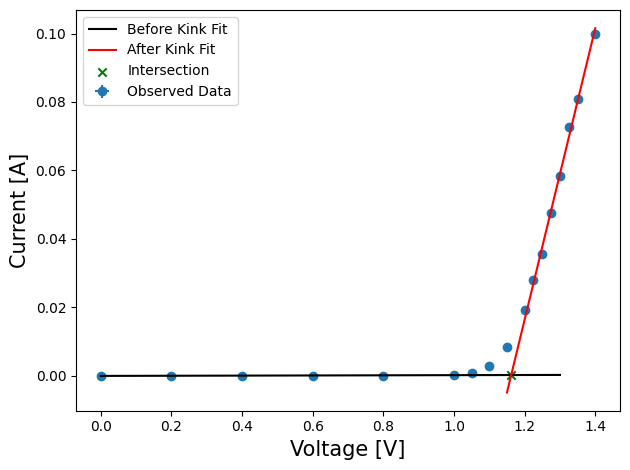

In [20]:
lambda950 = pd.read_csv('../data/950nm.txt', delimiter='\t')
voltage = lambda950['V (V)']
current = lambda950['I (A)']

kink_index = 6
plt.errorbar(
    voltage, 
    current,
    fmt='o',
    xerr=lambda950['dV (V)'],
    yerr=lambda950['dI (A)'],
    label='Observed Data'
)
popt, pcov = curve_fit(linear_fit, voltage[:kink_index], current[:kink_index])
m1, b1 = popt
m1_err, b1_err = np.sqrt(np.diag(pcov))
print(f'm1 =  {m1} +- {m1_err}')
print(f'b1 = {b1} +- {b1_err}')

popt_, pcov_ = curve_fit(linear_fit, voltage[kink_index + 4:], current[kink_index + 4:])
m2, b2 = popt_
m2_err, b2_err = np.sqrt(np.diag(pcov_))
print(f'm2 =  {m2} +- {m2_err}')
print(f'b2 = {b2} +- {b2_err}')
                         
plt.plot(
    voltage[:kink_index + 8],
    linear_fit(voltage[:kink_index + 8], *popt),
    c='k',
    label='Before Kink Fit',
    zorder=10,
)
plt.plot(
    voltage[kink_index + 2:],
    linear_fit(voltage[kink_index + 2:], *popt_),
    c='red',
    zorder=12,
    label='After Kink Fit'
)

x_int, y_int = find_intersection(*popt, *popt_)
x_int_err = uncertainty(*popt, *np.sqrt(np.diag(pcov)), *popt_, *np.sqrt(np.diag(pcov_)))
print(f'x_intersection = {x_int} +- {x_int_err}')
# print(f'y_intersection')

plt.scatter(x_int, y_int, color='green', marker='x', label='Intersection')

plt.xlabel('Voltage [V]', fontsize=fontsize)
plt.ylabel('Current [A]', fontsize=fontsize)
plt.legend()
plt.tight_layout()
plt.savefig('../tex/figures/950nm.png', dpi=300, bbox_inches='tight')
plt.show()

## Threshold voltage vs frequency

We are plotting voltage versus the emission frequency: 

We know that $$eV = \frac{hc}{\lambda}.$$
Then, $$V = \frac{hc}{\lambda e}.$$
By plotting voltage vs the frequency $(c/f)$, the slope will be $$m = \frac{h}{e} \implies h = m \cdot e$$.

Then, the error in h, $$\delta h = \delta m.$$

The intercept is going to be the work function.

m = 4.538996036675055e-15 +- 7.410553600508345e-16
b = -0.2849404628058393 +- 0.3984188282417158
h = 7.27227339177938e-34 +- 1.187301582373904e-34 J.s


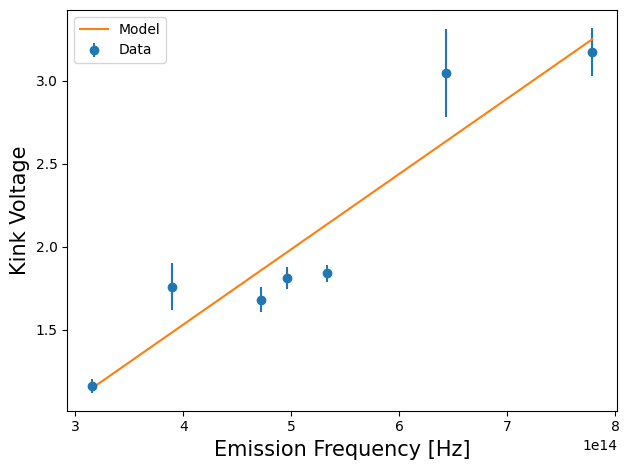

In [21]:
wavelength = np.array([385, 466, 563, 605, 635, 770, 950]) * 1e-9 # convert from nm to m
kink = np.array([3.170637991443616, 3.048219921425133, 1.8377434140600846, 1.810646713048507, 
        1.6803144727285977, 1.7590507294757223, 1.161991355540605]) # volts
kink_err = np.array([0.1450847266290695, 0.26512745927567133, 0.048689076630350644, 0.06801643810437732,
            0.0772569065959846, 0.1408575736041126, 0.04154278613422762]) # volts

c = 299792458 # m/s
e = 1.602176634e-19 # C
plt.errorbar(
    c / wavelength, 
    kink,
    fmt='o',
    yerr=kink_err,
    label='Data'
)

popt, pcov = curve_fit(linear_fit, c / wavelength, kink)
m, b = popt
m_err, b_err = np.sqrt(np.diag(pcov))
print(f'm = {m} +- {m_err}')
print(f'b = {b} +- {b_err}')
print(f'h = {m * e} +- {(e * m_err)} J.s')

plt.plot(c / wavelength, linear_fit(c / wavelength, *popt), label='Model')
plt.xlabel('Emission Frequency [Hz]', fontsize=fontsize)
plt.ylabel('Kink Voltage', fontsize=fontsize)
plt.tight_layout()
plt.savefig('../tex/figures/kink_volt_vs_emission_frequency.png', dpi=300, bbox_inches='tight')
plt.legend()
plt.show()

In [26]:
h_exp = 6.62607015e-34
print((h_exp - (m*e)) / h_exp)

-0.09752435865463635
